# 05 — Model Comparison: Logistic Regression vs. Gradient Boosting

This notebook compares the two modelling approaches from notebooks 03 and 04:

- **Logistic Regression (L1-regularized / LASSO)**: interpretable, coefficient-based
- **Gradient Boosting**: flexible, non-linear, SHAP-based interpretation

The goal is to decide which model is more suitable as a **first-pass screening tool** for heart disease risk. The model should flag patients who need further investigation. It does not aim to  replace a cardiologist.

Both notebooks 03 and 04 included `source_code` (hospital origin) as a feature. In both models, it ranked among the top 2 most important predictors. This is a problem. Hospital origin is not a clinical variable and should not drive a risk score. We therefore retrain both models without `source_code` and compare them on equal, clinically meaningful ground.

## Structure
1. Side-by-side performance comparison (with and without `source_code`)
2. Feature importance ranking comparison
3. Critical discussion: which features belong in a risk score?
4. Model recommendation and risk score derivation

In [1]:
import sys, os, warnings
sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score,
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

from src.utils import (
    RANDOM_STATE, load_processed_data, get_feature_target_split,
    get_column_groups, build_preprocessor,
)

FIGURES = "../results/figures"
TABLES  = "../results/tables"

plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 150})
pd.set_option("display.max_columns", 20)
print("Setup complete.")

Setup complete.


## 1 — Recap: Results with `source_code` included

Before retraining, here is what notebooks 03 and 04 produced when `source_code` was part of the feature set.

| Metric | Logistic Regression | Gradient Boosting |
|--------|--------------------:|------------------:|
| CV ROC-AUC | 0.8974 ± 0.0276 | 0.8903 ± 0.0254 |
| Test ROC-AUC | 0.9096 | 0.9176 |
| Accuracy (t=0.5) | 0.8478 | 0.8370 |
| Recall (t=0.3) | 0.9706 | 0.9706 |
| Specificity (t=0.3) | 0.6585 | 0.6585 |
| FN at t=0.3 | 3 | 3 |

Both models perform very similarly. At threshold 0.3, both miss only 3 out of 102 disease cases. The gradient boosting model has a slightly higher test AUC (0.918 vs 0.910), but the logistic regression has better cross-validation AUC (0.897 vs 0.890). The difference is negligible.

**The problem:** In both models, `source_code` is one of the top 2 predictors. The logistic regression assigns it rank 1 (aggregated coefficient magnitude), gradient boosting assigns it rank 2 (mean |SHAP|). This means both models partly learn "which hospital has more disease" rather than "which clinical pattern indicates disease".

This is not useful for a risk score. A doctor examining a new patient does not have a "source hospital" feature. And even if they did, the high importance of `source_code` reflects selection bias in how the four datasets were collected, not a real clinical signal.

## 2 — Retrain both models without `source_code`

We drop `source_code` and retrain both models with identical data splits, preprocessing, and evaluation. This gives us a fair comparison based on clinical features only.

In [2]:
# Load data and split â€” WITHOUT source_code
df = load_processed_data()
X, y = get_feature_target_split(df, drop_source=True, drop_high_missing=False)
groups = get_column_groups(X)

print(f"Features: {X.shape[1]}  (no source_code)")
print(f"Columns: {list(X.columns)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTrain: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Disease prevalence - Train: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}")

Features: 12  (no source_code)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'thal']

Train: 736  |  Test: 184
Disease prevalence - Train: 55.3%  |  Test: 55.4%


In [3]:
# Train both models
preprocessor = build_preprocessor(groups)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Logistic Regression (same config as notebook 03)
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        penalty="l1", solver="liblinear", max_iter=1000, random_state=RANDOM_STATE
    )),
])

# Gradient Boosting (same config as notebook 04)
pipe_gb = Pipeline([
    ("preprocessor", build_preprocessor(groups)),  # fresh preprocessor
    ("classifier", GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=2,
        min_samples_leaf=5, subsample=0.8, random_state=RANDOM_STATE
    )),
])

# Cross-validation
cv_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring="roc_auc")
cv_gb = cross_val_score(pipe_gb, X_train, y_train, cv=cv, scoring="roc_auc")

# Fit on full training set
pipe_lr.fit(X_train, y_train)
pipe_gb.fit(X_train, y_train)

# Predict probabilities
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]
y_prob_gb = pipe_gb.predict_proba(X_test)[:, 1]

print("Cross-validation ROC-AUC (without source_code):")
print(f"  LogReg:  {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"  GBM:     {cv_gb.mean():.4f} ± {cv_gb.std():.4f}")
print(f"\nTest ROC-AUC:")
print(f"  LogReg:  {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"  GBM:     {roc_auc_score(y_test, y_prob_gb):.4f}")

Cross-validation ROC-AUC (without source_code):
  LogReg:  0.8757 ± 0.0248
  GBM:     0.8742 ± 0.0253

Test ROC-AUC:
  LogReg:  0.8895
  GBM:     0.9093


## 3 — ROC Curve Comparison

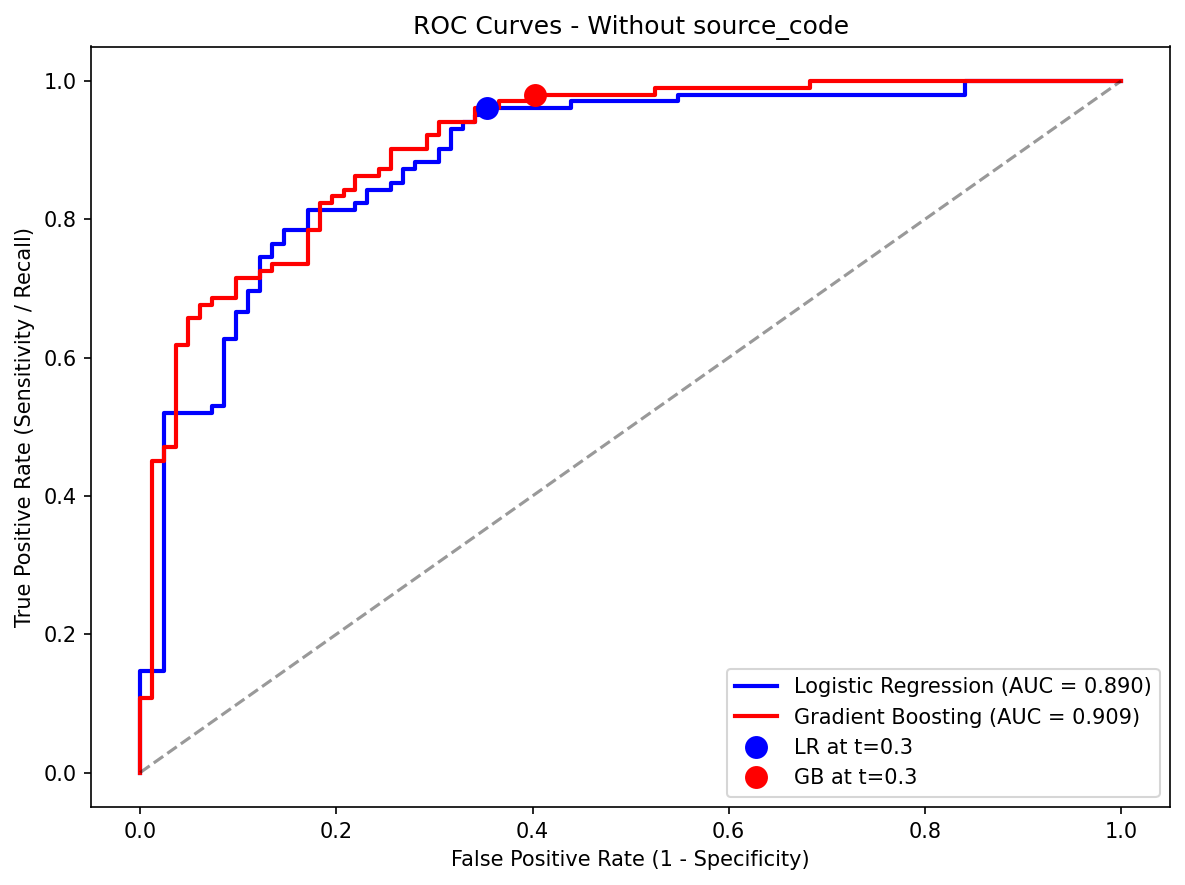

In [4]:
# ROC curves side by side
fpr_lr, tpr_lr, thresh_lr = roc_curve(y_test, y_prob_lr)
fpr_gb, tpr_gb, thresh_gb = roc_curve(y_test, y_prob_gb)
auc_lr = auc(fpr_lr, tpr_lr)
auc_gb = auc(fpr_gb, tpr_gb)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, "b-", lw=2, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
ax.plot(fpr_gb, tpr_gb, "r-", lw=2, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)

# Mark threshold 0.3 on both curves
for fpr_arr, tpr_arr, thresh_arr, color, name in [
    (fpr_lr, tpr_lr, thresh_lr, "blue", "LR"),
    (fpr_gb, tpr_gb, thresh_gb, "red", "GB"),
]:
    idx = np.argmin(np.abs(thresh_arr - 0.3))
    ax.plot(fpr_arr[idx], tpr_arr[idx], "o", color=color, markersize=10,
            label=f"{name} at t=0.3")

ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)")
ax.set_title("ROC Curves - Without source_code")
ax.legend(loc="lower right")
fig.savefig(f"{FIGURES}/comparison_roc_curves.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 4 — Threshold Comparison (t = 0.3)

Both notebooks selected t = 0.3 as the screening threshold. We compare the detailed metrics at this threshold for both models without `source_code`.

In [5]:
# Compare both models across thresholds
candidate_thresholds = [0.5, 0.4, 0.3, 0.2]
rows = []

for name, y_prob in [("LogReg", y_prob_lr), ("GBM", y_prob_gb)]:
    for thresh in candidate_thresholds:
        y_pred_t = (y_prob >= thresh).astype(int)
        cm = confusion_matrix(y_test, y_pred_t)
        tn, fp, fn, tp = cm.ravel()
        rows.append({
            "Model": name,
            "Threshold": thresh,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "Accuracy": accuracy_score(y_test, y_pred_t),
            "Precision": precision_score(y_test, y_pred_t, zero_division=0),
            "Recall": recall_score(y_test, y_pred_t),
            "Specificity": tn / (tn + fp),
            "F1": f1_score(y_test, y_pred_t),
        })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(f"{TABLES}/comparison_threshold_metrics.csv", index=False)

print("Performance comparison WITHOUT source_code:\n")
comparison_df.round(4)

Performance comparison WITHOUT source_code:



,Model,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall,Specificity,F1
0,LogReg,0.5,87,21,15,61,0.8043,0.8056,0.8529,0.7439,0.8286
1,LogReg,0.4,95,26,7,56,0.8207,0.7851,0.9314,0.6829,0.8520
2,LogReg,0.3,98,31,4,51,0.8098,0.7597,0.9608,0.6220,0.8485
3,LogReg,0.2,99,39,3,43,0.7717,0.7174,0.9706,0.5244,0.8250
4,GBM,0.5,89,20,13,62,0.8207,0.8165,0.8725,0.7561,0.8436
5,GBM,0.4,96,25,6,57,0.8315,0.7934,0.9412,0.6951,0.8610
6,GBM,0.3,100,34,2,48,0.8043,0.7463,0.9804,0.5854,0.8475
7,GBM,0.2,101,43,1,39,0.7609,0.7014,0.9902,0.4756,0.8211


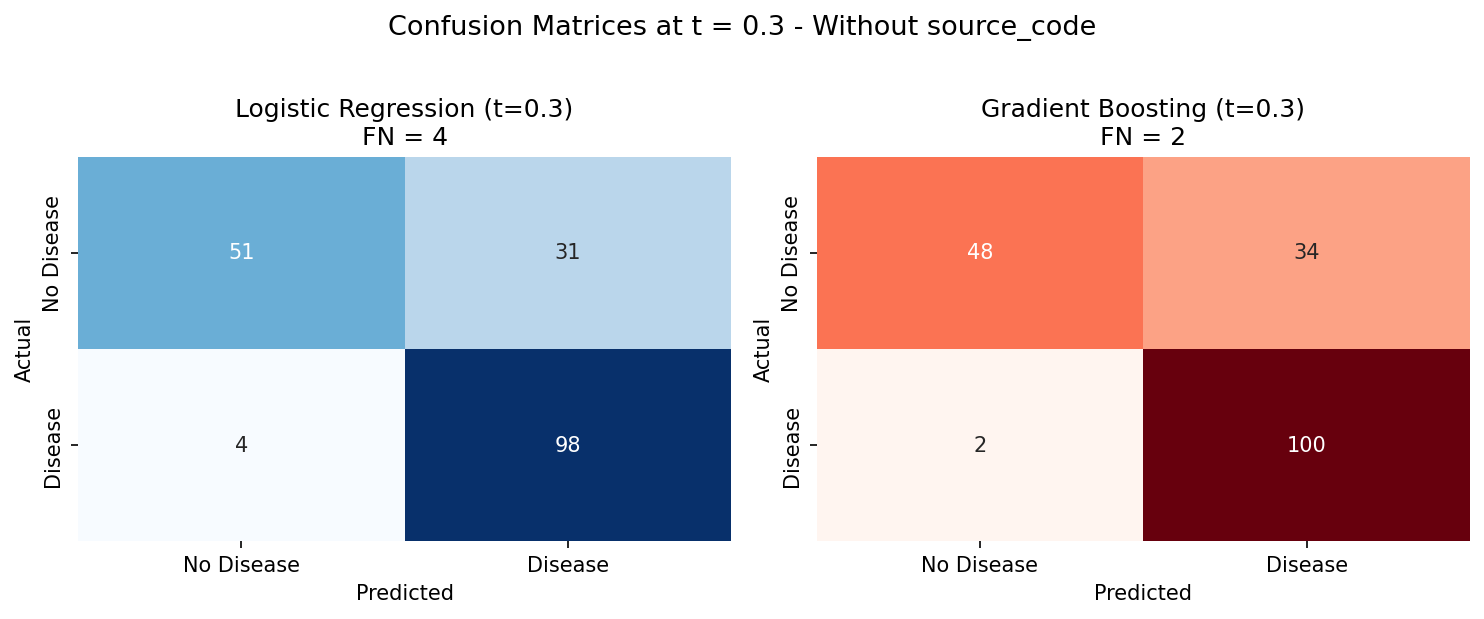

In [6]:
# Confusion matrices at t=0.3 side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
thresh = 0.3

for i, (name, y_prob, cmap) in enumerate([
    ("Logistic Regression", y_prob_lr, "Blues"),
    ("Gradient Boosting", y_prob_gb, "Reds"),
]):
    y_pred_t = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    fn = cm[1, 0]

    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"],
                ax=axes[i], cbar=False)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].set_title(f"{name} (t=0.3)\nFN = {fn}")

fig.suptitle("Confusion Matrices at t = 0.3 - Without source_code", fontsize=13, y=1.02)
fig.savefig(f"{FIGURES}/comparison_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 5 — Calibration: Are the predicted probabilities realistic?

For a risk score, we do not just need good discrimination (AUC) â€” we also need the predicted probabilities to be **well-calibrated**. If the model says "70% risk", roughly 70% of such patients should actually have disease.

This matters because we want to use the predicted probability directly as a risk score. A model with high AUC but poor calibration could assign misleading probabilities. The Brier score measures how close the predicted probabilities are to the actual outcomes (lower = better, 0 = perfect).

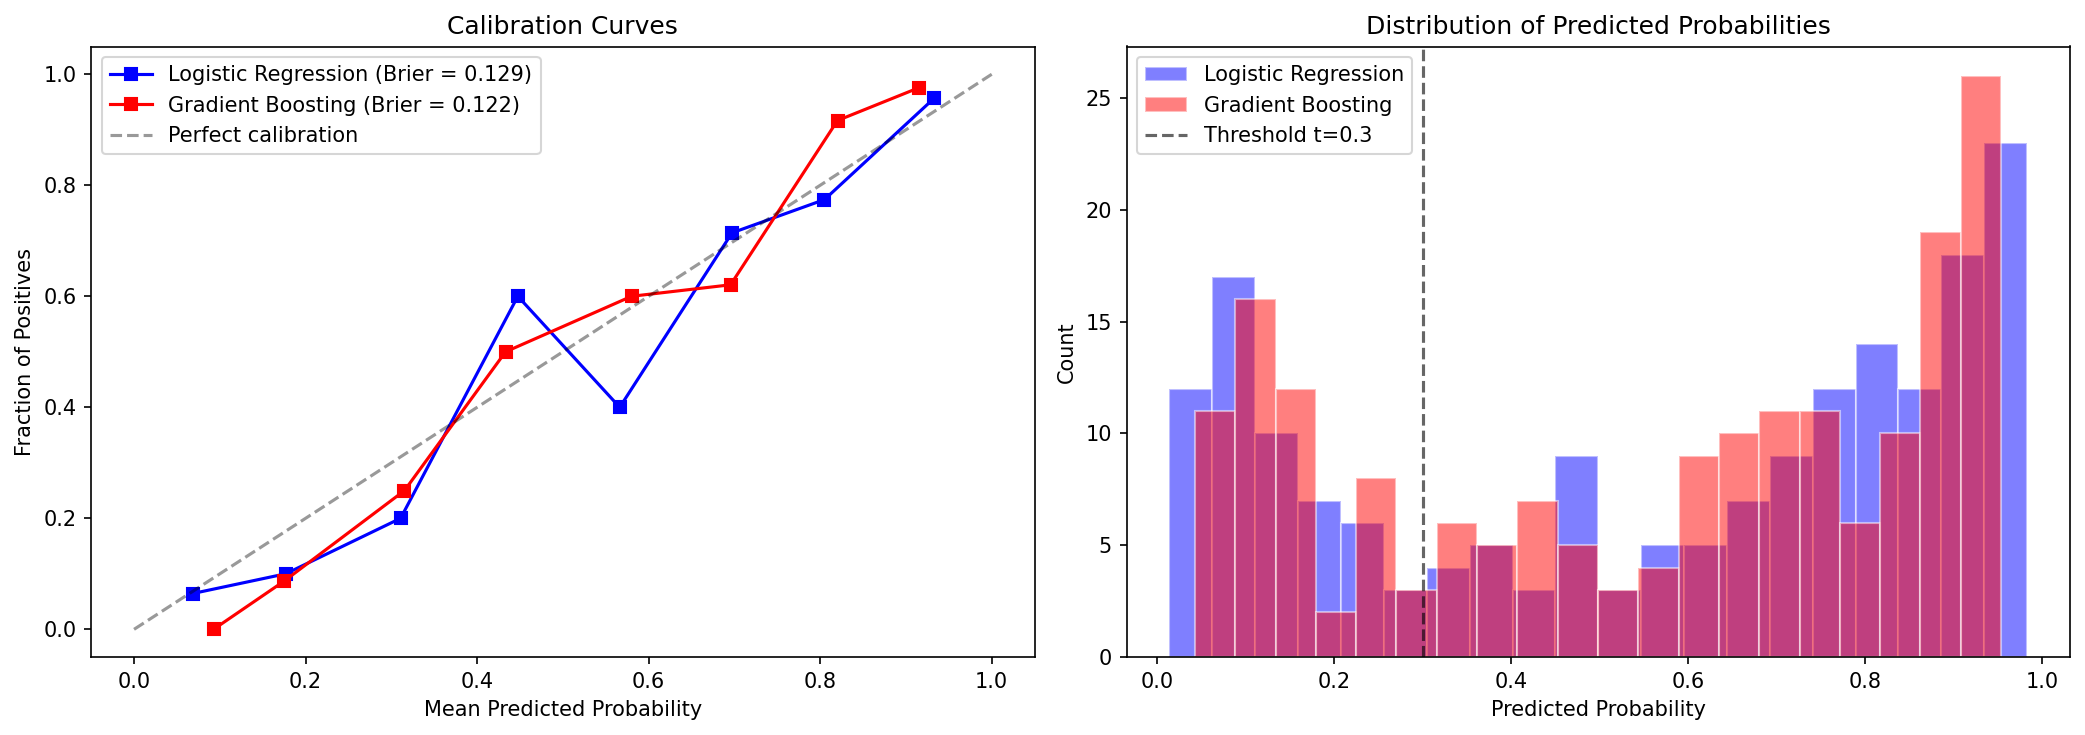

In [7]:
# Calibration curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, y_prob, color) in enumerate([
    ("Logistic Regression", y_prob_lr, "blue"),
    ("Gradient Boosting", y_prob_gb, "red"),
]):
    brier = brier_score_loss(y_test, y_prob)
    fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=8)

    axes[0].plot(mean_pred, fraction_pos, "s-", color=color,
                 label=f"{name} (Brier = {brier:.3f})")

    # Probability distribution
    axes[1].hist(y_prob, bins=20, alpha=0.5, color=color, label=name, edgecolor="white")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect calibration")
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Fraction of Positives")
axes[0].set_title("Calibration Curves")
axes[0].legend(loc="upper left")

axes[1].axvline(0.3, color="black", linestyle="--", alpha=0.6, label="Threshold t=0.3")
axes[1].set_xlabel("Predicted Probability")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Predicted Probabilities")
axes[1].legend()

fig.savefig(f"{FIGURES}/comparison_calibration.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 6 — Feature Importance Comparison

We compare which features each model considers most important. For logistic regression we use aggregated absolute coefficients, for gradient boosting we use the built-in feature importances (mean decrease in impurity).

If both models agree on the top features, this increases our confidence that these features carry genuine predictive signal rather than model-specific artifacts.

In [8]:
# Extract feature importances from both models

_MULTICLASS_ORIGINALS = ["cp", "restecg", "thal", "slope"]

def aggregate_importance(feature_names, importances):
    """Aggregate one-hot encoded features back to original variable names."""
    original = {}
    for name, imp in zip(feature_names, importances):
        orig = name
        for mc in _MULTICLASS_ORIGINALS:
            if name.startswith(mc + "_"):
                orig = mc
                break
        original[orig] = original.get(orig, 0) + abs(imp)
    result = pd.DataFrame(list(original.items()), columns=["feature", "importance"])
    result = result.sort_values("importance", ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    return result

# Get transformed feature names (clean)
preprocessor_lr = pipe_lr.named_steps["preprocessor"]
feat_names = [f.split("__")[-1] for f in preprocessor_lr.get_feature_names_out()]

# LogReg: absolute coefficients
lr_coefs = pipe_lr.named_steps["classifier"].coef_[0]
imp_lr = aggregate_importance(feat_names, lr_coefs)
imp_lr.columns = ["feature", "lr_importance", "lr_rank"]

# GBM: built-in feature importance
preprocessor_gb = pipe_gb.named_steps["preprocessor"]
feat_names_gb = [f.split("__")[-1] for f in preprocessor_gb.get_feature_names_out()]
gb_imp = pipe_gb.named_steps["classifier"].feature_importances_
imp_gb = aggregate_importance(feat_names_gb, gb_imp)
imp_gb.columns = ["feature", "gb_importance", "gb_rank"]

# Merge
rank_comparison = imp_lr.merge(imp_gb, on="feature", how="outer")
rank_comparison = rank_comparison.sort_values("lr_rank").reset_index(drop=True)
rank_comparison.to_csv(f"{TABLES}/comparison_feature_ranking.csv", index=False)

print("Feature ranking comparison (without source_code):\n")
rank_comparison

Feature ranking comparison (without source_code):



,feature,lr_importance,lr_rank,gb_importance,gb_rank
0,cp,2.446818,1,0.426989,1
1,thal,1.481969,2,0.046715,7
2,sex,1.303963,3,0.089151,5
3,exang,0.770049,4,0.103186,2
4,restecg,0.524919,5,0.003080,12
5,oldpeak,0.476962,6,0.091271,3
6,thalach,0.395584,7,0.090238,4
7,age,0.292989,8,0.083492,6
8,slope,0.239118,9,0.003206,11
9,chol,0.214378,10,0.046247,8


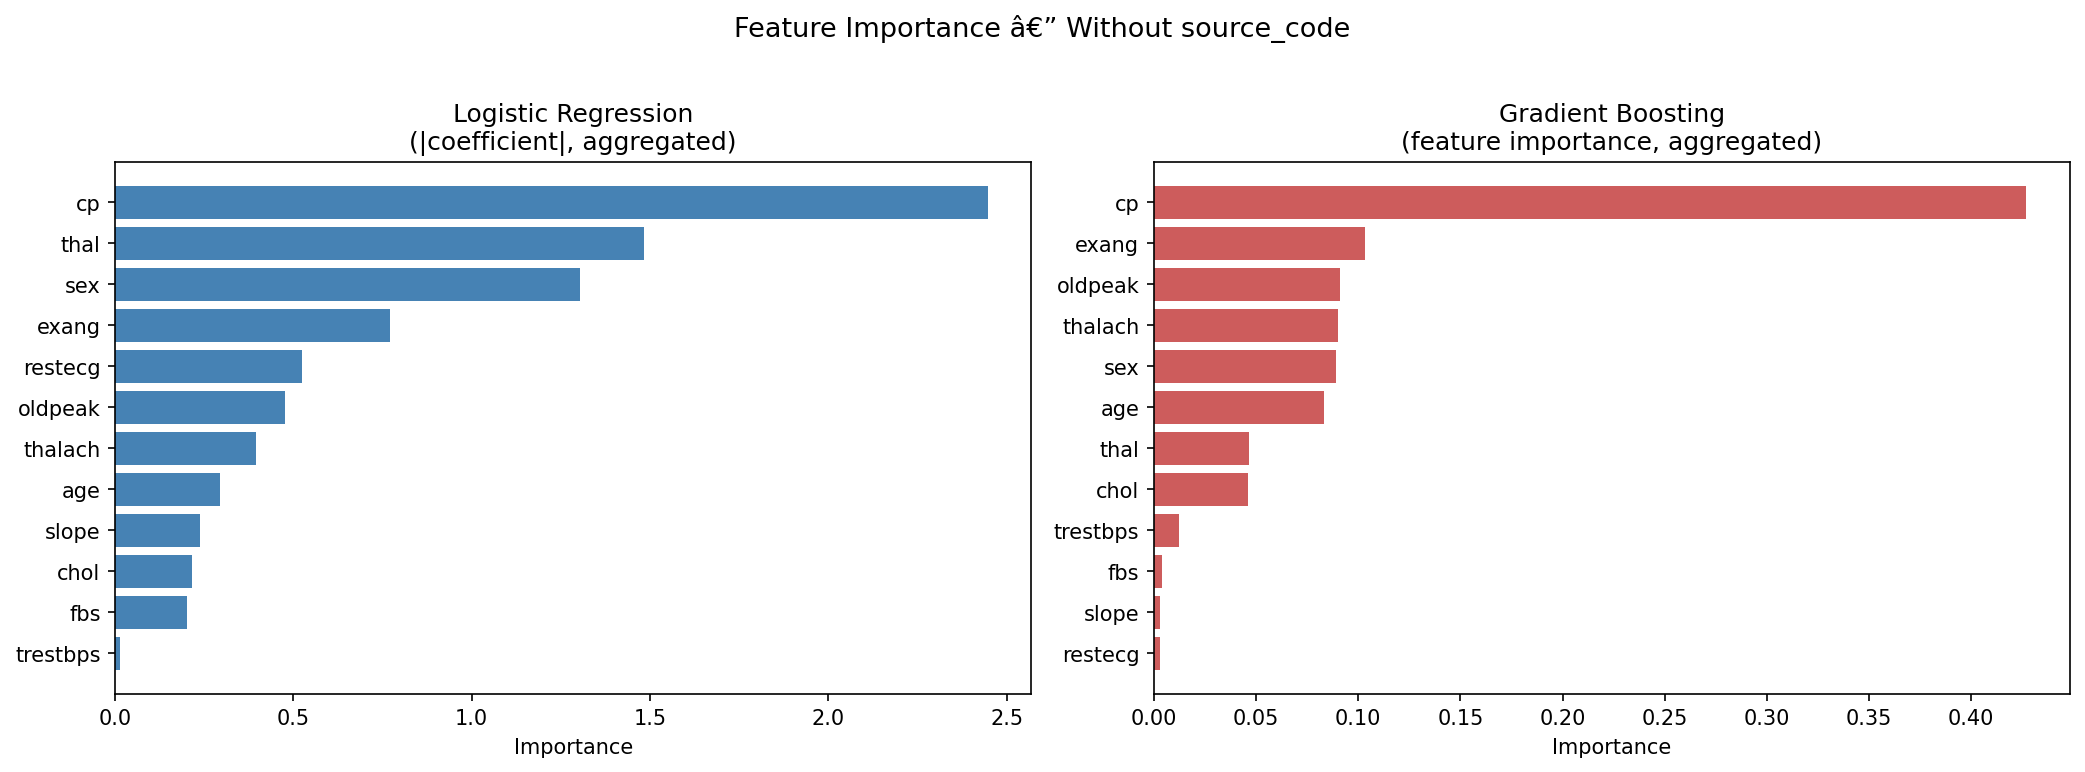

In [9]:
# Visual comparison of feature rankings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LogReg
lr_sorted = rank_comparison.sort_values("lr_importance", ascending=True)
axes[0].barh(lr_sorted["feature"], lr_sorted["lr_importance"], color="steelblue")
axes[0].set_title("Logistic Regression\n(|coefficient|, aggregated)")
axes[0].set_xlabel("Importance")

# GBM
gb_sorted = rank_comparison.sort_values("gb_importance", ascending=True)
axes[1].barh(gb_sorted["feature"], gb_sorted["gb_importance"], color="indianred")
axes[1].set_title("Gradient Boosting\n(feature importance, aggregated)")
axes[1].set_xlabel("Importance")

fig.suptitle("Feature Importance â€” Without source_code", fontsize=13, y=1.02)
fig.savefig(f"{FIGURES}/comparison_feature_importance.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 7 — Logistic Regression: Odds Ratios for Risk Score Interpretation

Since logistic regression is the model we recommend for the risk score (see discussion below), we show the odds ratios for the final model without `source_code`. These tell a doctor: "if this variable increases by one unit (or one SD for standardised variables), how does the odds of disease change?"

An odds ratio > 1 means higher risk, < 1 means protective.

**Important caveat on interpretation:** Odds ratios describe *associations*, not *interventions*. Some variables are **fixed risk factors** that cannot be changed (e.g. `sex`, `age`). A high odds ratio for `sex` does not mean "changing sex changes risk" — it means **being male is associated with higher baseline odds of disease**, all else equal. Fixed factors help *stratify* patient risk but are not actionable treatment targets. Only modifiable factors (e.g. exercise capacity, lifestyle) can be influenced by the patient or doctor.

In summary:
- **Fixed factors** (sex, age): define baseline risk profile — the patient "starts" at a higher or lower risk level
- **Clinical findings** (cp, exang, oldpeak, thalach, thal): describe the current cardiac state — these are what the doctor measures and interprets
- **Modifiable factors** (e.g. cholesterol, blood pressure, fasting blood sugar): can potentially be improved through treatment or lifestyle changes

In [10]:
# Odds ratios from the logistic regression model (without source_code)
coef_df = pd.DataFrame({
    "feature": feat_names,
    "coefficient": lr_coefs,
    "odds_ratio": np.exp(lr_coefs),
})
coef_df = coef_df.sort_values("odds_ratio", ascending=False).reset_index(drop=True)

print("Logistic Regression â€” Odds Ratios (without source_code):\n")
print("Features with odds_ratio > 1 INCREASE disease risk.")
print("Features with odds_ratio < 1 DECREASE disease risk.\n")
coef_df.round(4)

Logistic Regression â€” Odds Ratios (without source_code):

Features with odds_ratio > 1 INCREASE disease risk.
Features with odds_ratio < 1 DECREASE disease risk.



,feature,coefficient,odds_ratio
0,sex,1.3040,3.6839
1,thal_7.0,0.9947,2.7040
2,cp_4.0,0.8905,2.4362
3,exang,0.7700,2.1599
4,thal_6.0,0.4872,1.6278
5,oldpeak,0.4770,1.6112
6,restecg_1.0,0.3286,1.3890
7,age,0.2930,1.3404
8,slope_2.0,0.2391,1.2701
9,chol,0.2144,1.2391


## 8 — Critical Discussion

### 8.1 - Why we drop `source_code`

Both models ranked `source_code` in the top 2 features when it was included. This is not a useful clinical signal - it reflects **selection bias**:

- **Switzerland**: 93.5% disease prevalence. This is almost certainly a specialty cardiology clinic where nearly every patient was already suspected of having heart disease.
- **Long Beach VA**: 74.5%. Veterans hospitals serve populations with known cardiovascular risk factors.
- **Cleveland**: 45.9%. Cleveland Clinic is a referral center â€” mixed population.
- **Hungarian**: 36.1%. Closest to a general population sample.

The model learns "Swiss patients almost always have disease" - but that is a property of the dataset, not of being Swiss. A new patient walking into a clinic has no meaningful `source_code`. Including it would make the risk score non-transferable and artificially inflated.

The original idea to check whether certain regions show different disease rates (e.g. due to cultural eating habits or environmental factors) is interesting in principle. But it does not work here because:
1. The datasets are small (123 to 303 patients each) - not representative of their populations.
2. The selection criteria for inclusion in each dataset were different (screening vs. referral vs. specialty clinic).
3. We have no information about ethnicity, diet, or lifestyle - so `source_code` is a confounded proxy at best.

**Dropping `source_code` is the right call.** The model should learn clinical patterns, not dataset labels.

### 8.2 - Logistic Regression vs. Gradient Boosting: Which model to use?

Both models achieve very similar performance. This is actually expected - with only 920 samples and 12 clinical features, there is limited room for a complex model to outperform a simple one. The dataset is probably not big enough for gradient boosting to exploit its non-linear capacity.

**We recommend logistic regression** for the risk score, for three reasons:

1. **Interpretability.** Logistic regression produces coefficients and odds ratios that a doctor can understand. "Asymptomatic chest pain (cp=4) doubles the odds of disease" is actionable. Gradient boosting is a black box - SHAP values help, but they are approximations and harder to communicate.

2. **Probability output.** Logistic regression directly models log-odds. Its probability output is a natural sigmoid, well-suited for a risk score. Gradient boosting produces probabilities too, but they are derived from aggregated tree predictions and tend to be less well-calibrated without additional post-processing (e.g. Platt scaling).

3. **No meaningful performance gap.** If gradient boosting had substantially higher AUC, the interpretability trade-off might be worth it. But it does not. Both models perform within 1-2 percentage points of each other. There is no reason to sacrifice transparency for negligible gains.

### 8.3 - Features to include in the risk score

Based on the ranking agreement between both models (and medical plausibility), the following features are strong candidates for a risk score:

| Feature | What it measures | Both models agree? |
|---------|-----------------|-------------------|
| `cp` (chest pain type) | Symptom presentation | Yes - top predictor in both |
| `exang` (exercise-induced angina) | Stress test finding | Yes - top 5 in both |
| `oldpeak` (ST depression) | ECG finding during exercise | Yes - top 5 in both |
| `sex` | Demographic | Yes - top 5 in both |
| `thal` (thalassemia test) | Blood test result | Yes - top 6 in both |
| `thalach` (max heart rate) | Stress test finding | Yes - top 8 in both |
| `age` | Demographic | Yes - top 8 in both |

Features with low importance in both models (`fbs`, `restecg`, `trestbps`) contribute very little. They are not harmful to include (the L1 regularization handles them), but they also do not drive the risk score.

### 8.4 - Limitations to keep in mind

- **Gender imbalance.** ~79% of the dataset is male. The model has limited ability to learn female-specific patterns. Heart disease possibly presents differently in women, so the risk score may be less accurate for female patients.
- **Historical data.** The datasets are from the 1980s. Diagnostic standards, treatment options, and population health have changed. The model reflects patterns from 40 years ago.
- **Imputed variables.** `thal` (53% originally missing) and `slope` (34% missing) were imputed. The imputed values may carry artifacts. Despite this, `thal` still ranks highly - but we should be cautious about how much weight it carries.
- **Dataset size.** 920 samples is small. Both models show some variance across cross-validation folds (± 0.02-0.03 in AUC). The risk score should be treated as a rough indicator, not a precise diagnostic tool.

### 8.5 - How to use the risk score in practice

The logistic regression model outputs a probability between 0 and 1. This probability **is** the risk score. The recommended workflow:

1. Collect the 12 clinical features for a patient.
2. Feed them through the trained logistic regression pipeline.
3. The output probability = risk score.
4. If risk score >= 0.3: **flag for further investigation** (refer to cardiologist).
5. If risk score < 0.3: lower risk, but does not rule out disease entirely.

This threshold of 0.3 was chosen to minimize false negatives (missed disease cases). At this threshold, recall is ~97% - meaning the model catches almost all true disease cases. The trade-off is more false positives (~34% of healthy patients get flagged), but in a screening context, an unnecessary referral is far less costly than a missed diagnosis.

## 9 — Summary Table

In [11]:
# Final summary table
auc_lr_test = roc_auc_score(y_test, y_prob_lr)
auc_gb_test = roc_auc_score(y_test, y_prob_gb)
brier_lr = brier_score_loss(y_test, y_prob_lr)
brier_gb = brier_score_loss(y_test, y_prob_gb)

# Metrics at t=0.3
def metrics_at_threshold(y_true, y_prob, t):
    y_pred = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "Recall": recall_score(y_true, y_pred),
        "Specificity": tn / (tn + fp),
        "FN": fn,
        "FP": fp,
        "F1": f1_score(y_true, y_pred),
    }

m_lr = metrics_at_threshold(y_test, y_prob_lr, 0.3)
m_gb = metrics_at_threshold(y_test, y_prob_gb, 0.3)

summary = pd.DataFrame({
    "Metric": [
        "CV ROC-AUC (mean)", "CV ROC-AUC (std)",
        "Test ROC-AUC", "Brier Score",
        "Recall (t=0.3)", "Specificity (t=0.3)",
        "False Negatives (t=0.3)", "False Positives (t=0.3)",
        "F1 (t=0.3)",
        "Interpretable?", "Recommended?"
    ],
    "Logistic Regression": [
        f"{cv_lr.mean():.4f}", f"{cv_lr.std():.4f}",
        f"{auc_lr_test:.4f}", f"{brier_lr:.4f}",
        f"{m_lr['Recall']:.4f}", f"{m_lr['Specificity']:.4f}",
        m_lr["FN"], m_lr["FP"],
        f"{m_lr['F1']:.4f}",
        "Yes", "Yes"
    ],
    "Gradient Boosting": [
        f"{cv_gb.mean():.4f}", f"{cv_gb.std():.4f}",
        f"{auc_gb_test:.4f}", f"{brier_gb:.4f}",
        f"{m_gb['Recall']:.4f}", f"{m_gb['Specificity']:.4f}",
        m_gb["FN"], m_gb["FP"],
        f"{m_gb['F1']:.4f}",
        "No (black box)", "No"
    ],
})

summary.to_csv(f"{TABLES}/comparison_summary.csv", index=False)
print("Final Model Comparison (without source_code):\n")
summary

Final Model Comparison (without source_code):



,Metric,Logistic Regression,Gradient Boosting
0,CV ROC-AUC (mean),0.8757,0.8742
1,CV ROC-AUC (std),0.0248,0.0253
2,Test ROC-AUC,0.8895,0.9093
3,Brier Score,0.1290,0.1221
4,Recall (t=0.3),0.9608,0.9804
5,Specificity (t=0.3),0.6220,0.5854
6,False Negatives (t=0.3),4,2
7,False Positives (t=0.3),31,34
8,F1 (t=0.3),0.8485,0.8475
9,Interpretable?,Yes,No (black box)


## 10 — Conclusion

**Model choice:** Logistic regression. It is interpretable, produces well-calibrated probabilities, and performs just as well as gradient boosting on this dataset. The gradient boosting model confirms that the logistic regression is not missing important non-linear patterns. Both models agree on which features matter and achieve nearly identical performance.

**Risk score:** The predicted probability from the logistic regression model, using a screening threshold of 0.3. Patients scoring above 0.3 should be referred for further cardiac examination.

**Key predictors** (agreed by both models): chest pain type (`cp`), exercise-induced angina (`exang`), ST depression (`oldpeak`), sex, thalassemia result (`thal`), maximum heart rate (`thalach`), and age.

**Dropped:** `source_code` is not a clinical variable. It reflects dataset collection bias rather than genuine risk.

**Caveat:** This is a screening tool, not a diagnosis. The dataset is small, male-dominated, and 40 years old. The risk score should trigger further investigation, never replace clinical judgement.

## 11 — Simplified 5-Variable Risk Score

The full logistic regression uses 12 features (17 after one-hot encoding). For practical bedside use, a doctor needs a formula they can compute by hand — ideally with no more than 5 input variables.

**Yes, this is a logistic regression function.** The risk score is:

$$\text{score} = \frac{1}{1 + e^{-z}}, \quad \text{where} \quad z = b_0 + b_1 x_1 + b_2 x_2 + \ldots + b_5 x_5$$

If score > 0.3 → recommend referral to cardiologist.

We retrain a logistic regression with only 5 variables that are:
1. Among the top predictors in both models
2. Easy for a doctor to assess at the bedside
3. A mix of demographics and clinical findings

**Selected variables:**
- `sex` (0 = female, 1 = male) — fixed demographic risk factor
- `cp_asymptomatic` (1 if chest pain type = 4 "asymptomatic", 0 otherwise) — simplifies the top predictor to a single yes/no question: "Does the patient report no chest pain symptoms?"
- `exang` (0 = no, 1 = yes) — exercise-induced angina
- `oldpeak` (continuous, in mm) — ST depression induced by exercise relative to rest
- `thalach` (continuous, in bpm) — maximum heart rate achieved during stress test

Note: we do **not** standardize continuous variables for the simplified model. This way the coefficients are directly interpretable on the original measurement scale (mm for oldpeak, bpm for thalach), and the doctor can plug in raw patient values without any transformation.

In [12]:
# Build simplified 5-variable dataset (no standardization — raw scale)
df_simple = df.copy()
df_simple["cp_asymptomatic"] = (df_simple["cp"] == 4).astype(int)

X_simple = df_simple[["sex", "cp_asymptomatic", "exang", "oldpeak", "thalach"]]
y_simple = df_simple["num"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, stratify=y_simple, random_state=RANDOM_STATE
)

# Logistic regression WITHOUT StandardScaler — coefficients on raw scale
from sklearn.linear_model import LogisticRegression

lr_simple = LogisticRegression(
    penalty="l1", solver="liblinear", max_iter=1000, random_state=RANDOM_STATE
)
lr_simple.fit(X_train_s, y_train_s)

# Cross-validation
cv_simple = cross_val_score(lr_simple, X_train_s, y_train_s, cv=cv, scoring="roc_auc")
y_prob_simple = lr_simple.predict_proba(X_test_s)[:, 1]
auc_simple = roc_auc_score(y_test_s, y_prob_simple)

print(f"Simplified 5-variable model:")
print(f"  CV ROC-AUC:   {cv_simple.mean():.4f} ± {cv_simple.std():.4f}")
print(f"  Test ROC-AUC: {auc_simple:.4f}")

# Performance at t=0.3
y_pred_s03 = (y_prob_simple >= 0.3).astype(int)
cm_s = confusion_matrix(y_test_s, y_pred_s03)
tn, fp, fn, tp = cm_s.ravel()
print(f"\n  At threshold 0.3:")
print(f"    Recall:      {recall_score(y_test_s, y_pred_s03):.4f}")
print(f"    Specificity: {tn / (tn + fp):.4f}")
print(f"    FN:          {fn}")
print(f"    FP:          {fp}")

# Extract coefficients
coef_names = ["sex", "cp_asymptomatic", "exang", "oldpeak", "thalach"]
coefs = lr_simple.coef_[0]
intercept = lr_simple.intercept_[0]

print(f"\n{'='*60}")
print(f"RISK SCORE FORMULA")
print(f"{'='*60}")
print(f"\n  z = {intercept:.4f}")
for name, c in zip(coef_names, coefs):
    print(f"      + {c:+.4f} × {name}")
print(f"\n  score = 1 / (1 + exp(-z))")
print(f"\n  If score > 0.3  →  refer to cardiologist")

Simplified 5-variable model:
  CV ROC-AUC:   0.8678 ± 0.0211
  Test ROC-AUC: 0.8950

  At threshold 0.3:
    Recall:      0.9510
    Specificity: 0.5610
    FN:          5
    FP:          36

RISK SCORE FORMULA

  z = 0.0397
      + +1.4560 × sex
      + +1.5686 × cp_asymptomatic
      + +0.8658 × exang
      + +0.5735 × oldpeak
      + -0.0180 × thalach

  score = 1 / (1 + exp(-z))

  If score > 0.3  →  refer to cardiologist


In [13]:
# Example: compute risk score for a hypothetical patient
def risk_score(sex, cp_asymptomatic, exang, oldpeak, thalach):
    """Compute heart disease risk score (0-1) from 5 clinical variables.
    
    Parameters
    ----------
    sex : int              0 = female, 1 = male
    cp_asymptomatic : int  1 = no chest pain symptoms, 0 = has chest pain
    exang : int            1 = exercise-induced angina, 0 = none
    oldpeak : float        ST depression (mm) during exercise
    thalach : float        Maximum heart rate achieved (bpm)
    
    Returns
    -------
    float : risk score between 0 and 1
    """
    z = intercept
    z += coefs[0] * sex
    z += coefs[1] * cp_asymptomatic
    z += coefs[2] * exang
    z += coefs[3] * oldpeak
    z += coefs[4] * thalach
    return 1 / (1 + np.exp(-z))

# Example patients
examples = [
    {"sex": 1, "cp_asymptomatic": 1, "exang": 1, "oldpeak": 2.5, "thalach": 120,
     "desc": "Male, asymptomatic CP, exercise angina, high ST depression, low HR"},
    {"sex": 0, "cp_asymptomatic": 0, "exang": 0, "oldpeak": 0.0, "thalach": 170,
     "desc": "Female, has chest pain, no exercise angina, no ST depression, high HR"},
    {"sex": 1, "cp_asymptomatic": 0, "exang": 0, "oldpeak": 1.0, "thalach": 150,
     "desc": "Male, has chest pain, no exercise angina, moderate ST depression, normal HR"},
]

print("Example risk scores:\n")
for ex in examples:
    score = risk_score(ex["sex"], ex["cp_asymptomatic"], ex["exang"], ex["oldpeak"], ex["thalach"])
    referral = "REFER" if score > 0.3 else "LOW RISK"
    print(f"  {ex['desc']}")
    print(f"  → score = {score:.3f}  [{referral}]\n")

Example risk scores:

  Male, asymptomatic CP, exercise angina, high ST depression, low HR
  → score = 0.961  [REFER]

  Female, has chest pain, no exercise angina, no ST depression, high HR
  → score = 0.046  [LOW RISK]

  Male, has chest pain, no exercise angina, moderate ST depression, normal HR
  → score = 0.346  [REFER]



### Performance comparison: 5-variable vs. full model

The simplified model uses only 5 variables compared to 12 (17 after encoding) in the full model. The key question is how much discriminative power we lose.

The simplified model drops `thal` (which had 53% missing data originally and required heavy imputation) and `age` (which adds only marginal predictive power when the other variables are present). This is actually a benefit — the formula is more robust because it does not rely on heavily imputed features.

**For a doctor at the bedside, this formula requires only:**
1. Patient's sex (known)
2. One question: "Do you experience chest pain?" → if no → cp_asymptomatic = 1
3. Stress test result: exercise-induced angina? (yes/no)
4. ECG reading: ST depression value (oldpeak, in mm)
5. Stress test reading: maximum heart rate (thalach, in bpm)

Items 3-5 come from a standard exercise stress test, which is routinely performed when cardiac risk is being assessed. The formula can be computed with a pocket calculator.